<a href="https://colab.research.google.com/github/fadeeva/nakedML/blob/master/MLnotes/004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from scipy import stats
from scipy.spatial import distance_matrix
from scipy.sparse.csgraph import connected_components
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.cluster.hierarchy import fclusterdata, linkage, fcluster

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
import kagglehub

path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")
print("Path to dataset files:", path)

100%|██████████| 119k/119k [00:00<00:00, 15.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kumarajarshi/life-expectancy-who/versions/1


In [3]:
rng = np.random.default_rng()

In [4]:
df = pd.read_csv(f'{path}/Life Expectancy Data.csv')
df.drop(['Country', 'Year', 'Status'], inplace=True, axis=1)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.columns = [col.strip().lower() for col in df.columns]
df.head()

,life expectancy,adult mortality,infant deaths,alcohol,percentage expenditure,hepatitis b,measles,bmi,under-five deaths,polio,total expenditure,diphtheria,hiv/aids,gdp,population,thinness 1-19 years,thinness 5-9 years,income composition of resources,schooling
0,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# 04/

# Clustering



**Purpose / Why it's used:**

 - To measure the degree of similarity between objects.
 - To speed up further data processing.
 - To reduce the volume of stored data.
 - To detect outliers.
 - For feature selection (selecting one representative feature from each cluster).

```
If an algorithm uses a distance metric on a set of objects,
then the values of all features must be normalized beforehand.
```

In [5]:
standrtzt = lambda row: (row - row.mean()) / row.std() # normalization
em_distance = lambda p, q: np.round(np.sqrt(np.sum((p - q) ** 2)), 3)

def em_distance_pairs(data): # i don't use it because it's extremly sloooooooooooow
    n = data.shape[0]
    dist = np.zeros((n, n))

    for i in range(n):
        for j in range(i+1, n):
            d = em_distance(data.iloc[i], data.iloc[j])
            dist[i, j], dist[j, i] = d, d

    return dist


## Threshold-based Clustering

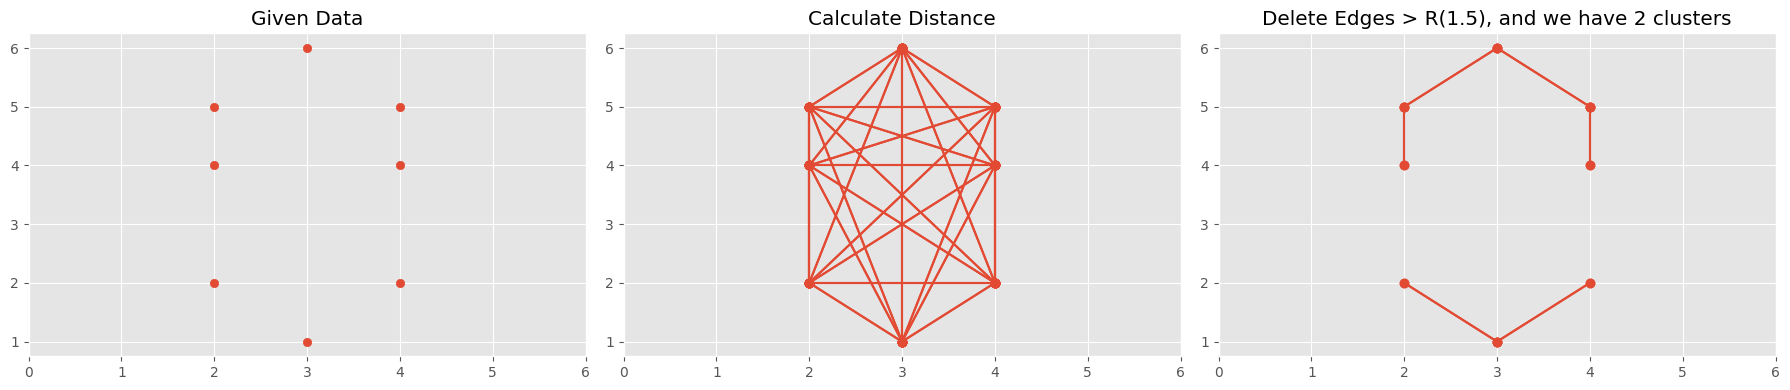

In [6]:
data = np.array([
    [2, 3, 4, 4, 4, 3, 2, 2],
    [5, 6, 5, 4, 2, 1, 2, 4]
])

fig, axs = plt.subplots(1, 3, figsize=(18, 4))

axs[0].scatter(data[0], data[1])
axs[0].set_xlim(0, 6)
axs[0].set_title('Given Data')

for i in range(len(data[0])):
    for j in range(len(data[0])):
        if i==j: continue

        X = [data[0][i], data[0][j]]
        Y = [data[1][i], data[1][j]]
        axs[1].plot(X, Y, marker='o', c='#E24A33')

axs[1].set_xlim(0, 6)
axs[1].set_title('Calculate Distance')

R = 1.5
for i in range(len(data[0])):
    for j in range(len(data[0])):
        dot_1 = np.array([data[0][i], data[1][i]])
        dot_2 = np.array([data[0][j], data[1][j]])
        dist = em_distance(dot_1, dot_2)

        if i==j or dist > R: continue

        X = [data[0][i], data[0][j]]
        Y = [data[1][i], data[1][j]]
        axs[2].plot(X, Y, marker='o', c='#E24A33')

axs[2].set_xlim(0, 6)
axs[2].set_title(f'Delete Edges > R({R}), and we have 2 clusters')

plt.tight_layout()

In [7]:
features = [
    'life expectancy',
    'alcohol',
]

clust_al_1 = df[['life expectancy', 'alcohol']].copy()

Text(0, 0.5, 'alcohol')

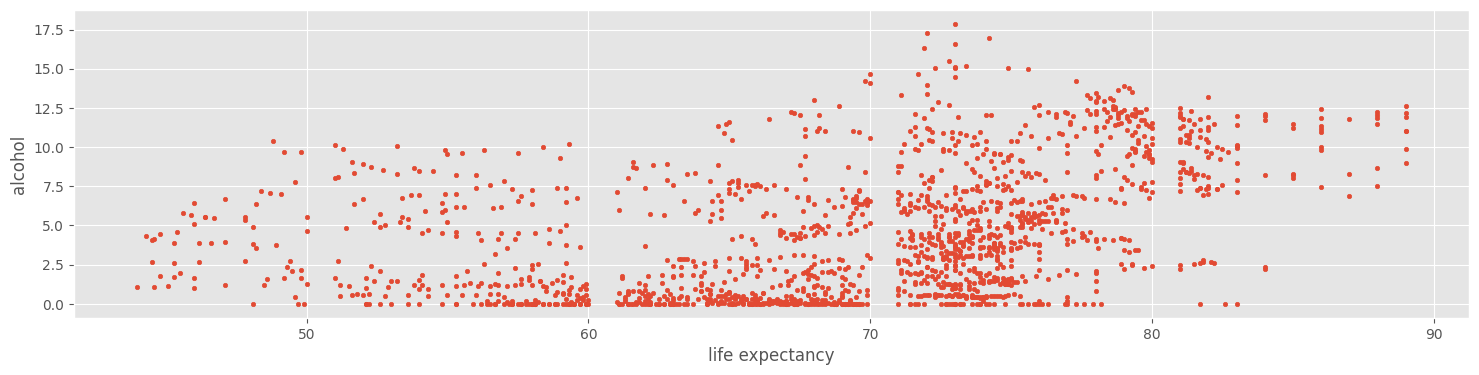

In [8]:
plt.figure(figsize=(18, 4))

plt.scatter(clust_al_1[features[0]], clust_al_1[features[1]], s=10)
plt.xlabel(features[0])
plt.ylabel(features[1])


In [9]:
clust_al_1[features[0]] = standrtzt(clust_al_1[features[0]])
clust_al_1[features[1]] = standrtzt(clust_al_1[features[1]])

# clust_al_1_dist = pd.DataFrame(
#     data=distance_matrix(clust_al_1.values, clust_al_1.values),
#     index=clust_al_1.index,
#     columns=clust_al_1.index
# )

clust_al_1_dist = distance_matrix(clust_al_1.values, clust_al_1.values)

In [10]:
threshold = .2
clust_al_1_dist[clust_al_1_dist > threshold] = np.nan
np.fill_diagonal(clust_al_1_dist, np.nan)
clust_al_1_dist = np.round(clust_al_1_dist, 2)

In [11]:
adj_matrix = np.where(~np.isnan(clust_al_1_dist), 1, 0)
n_components, labels = connected_components(csgraph=adj_matrix, directed=False)

print(f'Number of Clusters: {n_components}')

Number of Clusters: 17


In [12]:
clust_al_1['cluster'] = labels
clust_al_1.head()

,life expectancy,alcohol,cluster
0,-0.489074,-1.122607,0
1,-1.068828,-1.122607,0
2,-1.068828,-1.122607,0
3,-1.114299,-1.122607,0
4,-1.148402,-1.122607,0


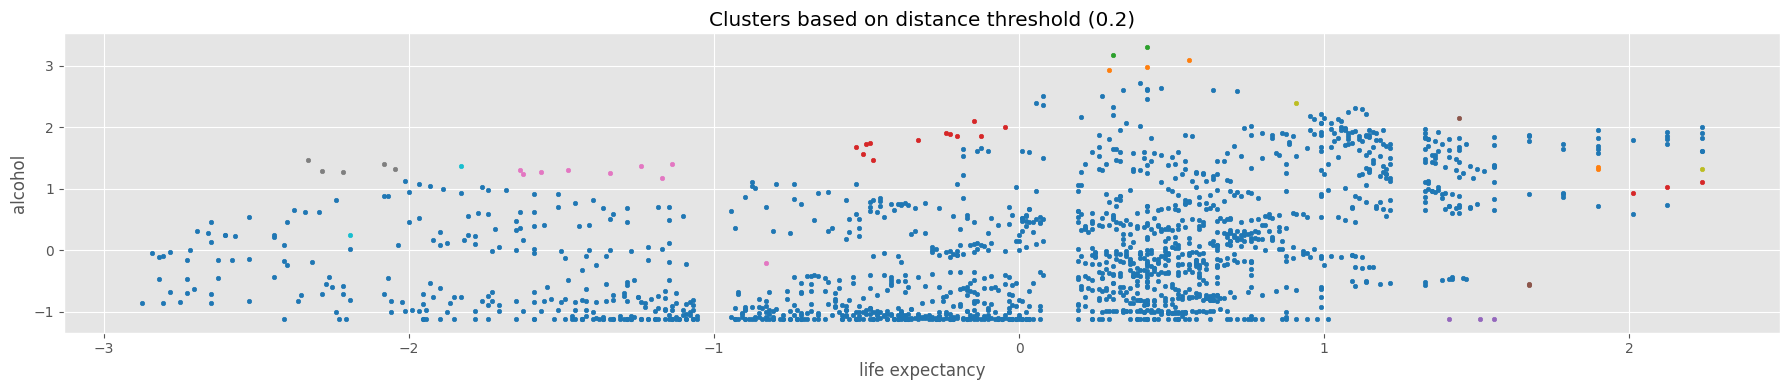

In [13]:
plt.figure(figsize=(18, 4))

colors = plt.cm.tab10(np.linspace(0, 1, n_components))

for cluster_id in range(n_components):
    subset = clust_al_1[clust_al_1['cluster'] == cluster_id]
    plt.scatter(subset[features[0]], subset[features[1]],
                s=10, marker='o', color=colors[cluster_id])

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(f'Clusters based on distance threshold ({threshold})')
plt.tight_layout()

## Minimum Spanning Tree (MST) based Clusterisation

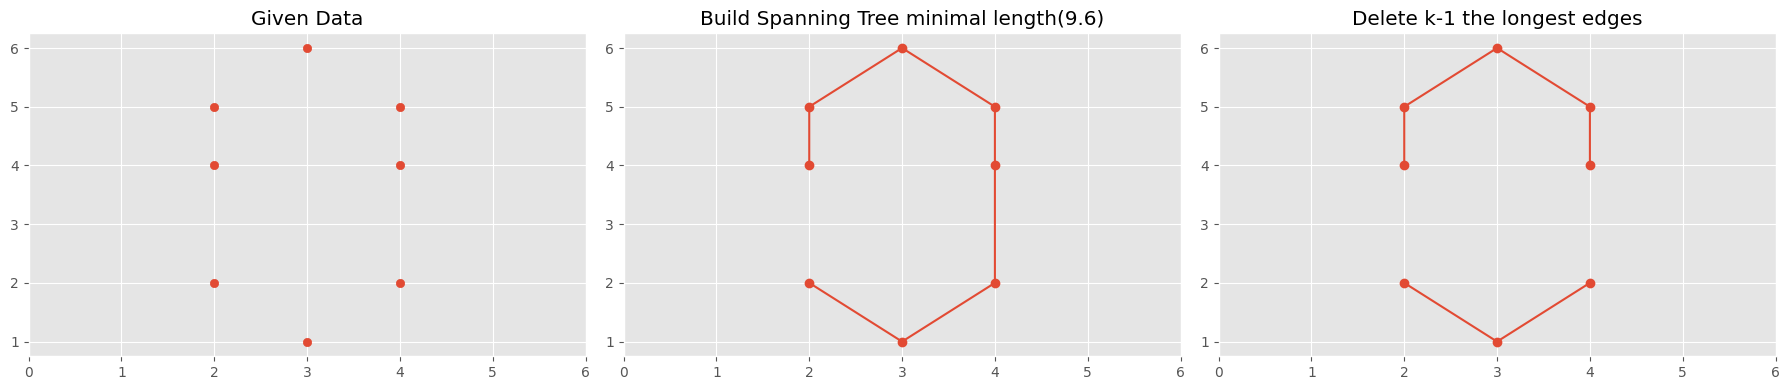

In [22]:
data = np.array([
    [2, 3, 4, 4, 4, 3, 2, 2],
    [5, 6, 5, 4, 2, 1, 2, 4]
])

k = 2 # number of clusters

fig, axs = plt.subplots(1, 3, figsize=(18, 4))

axs[0].scatter(data[0], data[1])
axs[0].set_xlim(0, 6)
axs[0].set_title('Given Data')

axs[1].plot(
    [2, 2, 3, 4, 4, 4, 3, 2],
    [4, 5, 6, 5, 4, 2, 1, 2],
    marker='o', c='#E24A33')

axs[1].set_xlim(0, 6)
axs[1].set_title('Build Spanning Tree minimal length(9.6)')

axs[2].plot(
    [2, 2, 3, 4, 4],
    [4, 5, 6, 5, 4],
    marker='o', c='#E24A33')
axs[2].plot(
    [4, 3, 2],
    [2, 1, 2],
    marker='o', c='#E24A33')

axs[2].set_xlim(0, 6)
axs[2].set_title(f'Delete k-1 the longest edges')

plt.tight_layout()

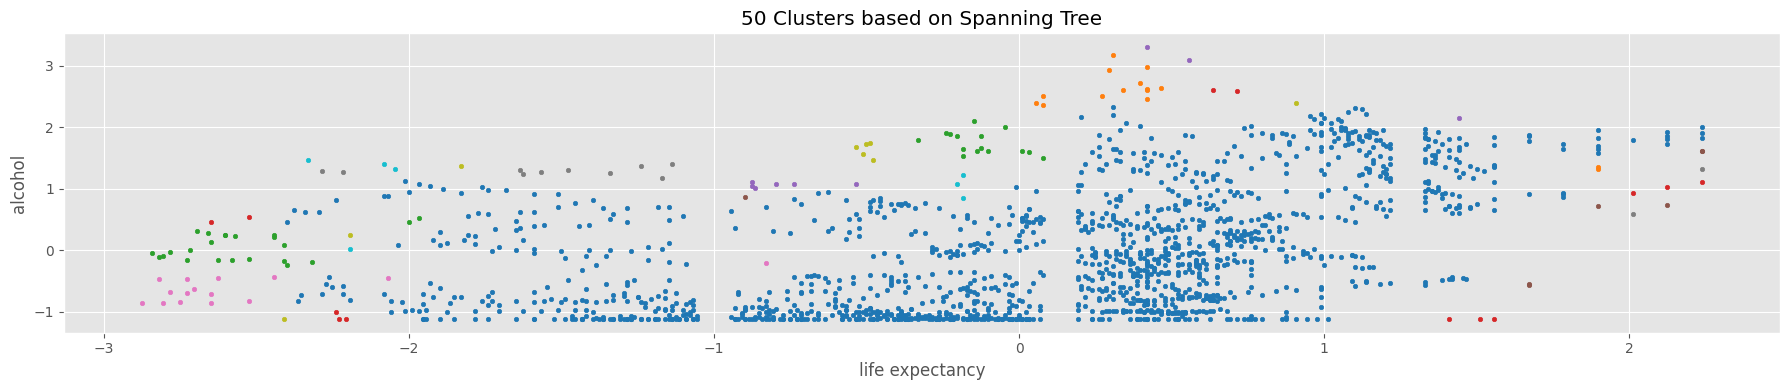

In [23]:
features = [
    'life expectancy',
    'alcohol',
]

clust_al_2 = df[['life expectancy', 'alcohol']].copy()

clust_al_2[features[0]] = standrtzt(clust_al_2[features[0]])
clust_al_2[features[1]] = standrtzt(clust_al_2[features[1]])

clust_al_2_dist = distance_matrix(clust_al_2.values, clust_al_2.values)
mst_matrix = minimum_spanning_tree(clust_al_2_dist)
mst_dense = mst_matrix.toarray().astype(float)

# mst_matrix.sum() # spanning tree length

edges = []
n = clust_al_2.shape[0]
for i in range(n):
    for j in range(i+1, n):
        if mst_dense[i, j] > 0:
            edges.append((mst_dense[i, j], i, j))

edges_sorted = sorted(edges, key=lambda x: x[0], reverse=True)

k = 50
edges_to_remove = edges_sorted[:k-1]

mst_filtered = mst_dense.copy()
for weight, i, j in edges_to_remove:
    mst_filtered[i, j] = 0
    mst_filtered[j, i] = 0

n_components, labels = connected_components(csgraph=mst_filtered, directed=False)

clust_al_2['cluster'] = labels

plt.figure(figsize=(18, 4))

colors = plt.cm.tab10(np.linspace(0, 1, n_components))

for cluster_id in range(n_components):
    subset = clust_al_2[clust_al_2['cluster'] == cluster_id]
    plt.scatter(subset[features[0]], subset[features[1]],
                s=10, marker='o', color=colors[cluster_id])

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(f'{k} Clusters based on Spanning Tree')
plt.tight_layout()


## Single-Linkage Clustering

In [14]:
clust_al_1_lib = df[['life expectancy', 'alcohol']].copy()

clust_al_1_lib['clusters'] = fclusterdata(
    clust_al_1_lib, t=threshold,
    criterion='distance', method='single'
)

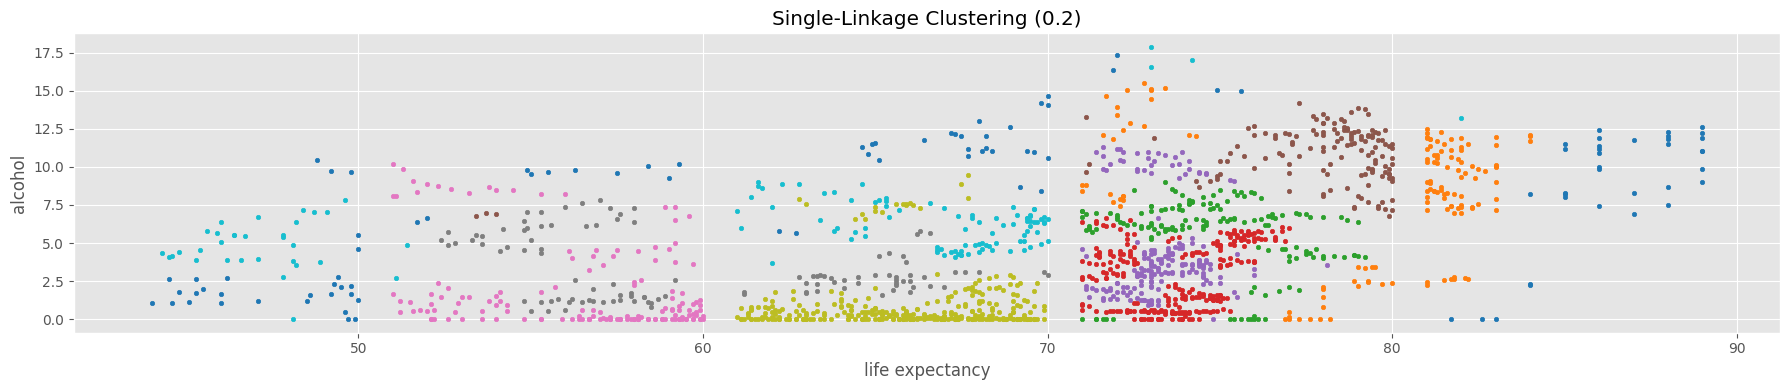

In [15]:
n_components = clust_al_1_lib['clusters'].nunique()

plt.figure(figsize=(18, 4))

colors = plt.cm.tab10(np.linspace(0, 1, n_components))

for cluster_id in range(n_components):
    subset = clust_al_1_lib[clust_al_1_lib['clusters'] == cluster_id]
    plt.scatter(subset[features[0]], subset[features[1]],
                s=10, marker='o', color=colors[cluster_id])

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(f'Single-Linkage Clustering ({threshold})')
plt.tight_layout()

## "maxclust" Criterion

Partitioning the Dendrogram to Obtain a Specified Number of clusters

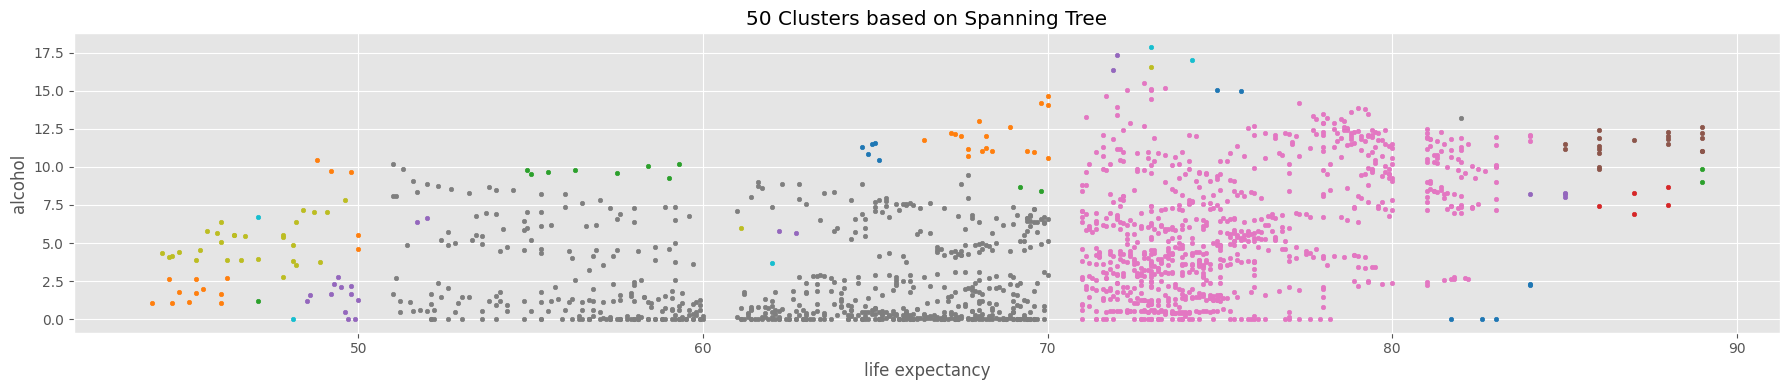

In [21]:
clust_al_2_lib = df[['life expectancy', 'alcohol']].copy()

Z = linkage(clust_al_2_lib, method='single')

k = 50
clust_al_2_lib['clusters'] = fcluster(Z, t=k, criterion='maxclust')

plt.figure(figsize=(18, 4))

colors = plt.cm.tab10(np.linspace(0, 1, k))

for cluster_id in range(k):
    subset = clust_al_2_lib[clust_al_2_lib['clusters'] == cluster_id]
    plt.scatter(subset[features[0]], subset[features[1]],
                s=10, marker='o', color=colors[cluster_id])

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(f'{k} Clusters based on Spanning Tree')
plt.tight_layout()